#  Advanced Prediction Notebook 
## Time Series · Deep Learning · AutoML · Anomaly · Survival · Model Serving

---
**Covers:**
- Time Series Forecasting (ARIMA, Prophet, LSTM)
- Neural Network Classifiers (MLP, custom PyTorch/TF)
- AutoML (auto-sklearn / TPOT concept)
- Anomaly Detection
- Survival Analysis
- Multi-label & Multi-output Prediction
- Calibration & Threshold Optimization
- Model Serialization & Serving
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
import joblib, pickle
from datetime import datetime, timedelta

from sklearn.datasets import make_multilabel_classification, make_classification
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, f1_score
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42


# Optional heavy imports
try:
    import xgboost as xgb; XGB_OK = True
except ImportError:
    XGB_OK = False

try:
    import lightgbm as lgb; LGB_OK = True
except ImportError:
    LGB_OK = False

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks
    TF_OK = True; print(f' TensorFlow {tf.__version__}')
except ImportError:
    TF_OK = False; print('  pip install tensorflow')

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True; print(f' PyTorch {torch.__version__}')
except ImportError:
    TORCH_OK = False; print('  pip install torch')

try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.stattools import adfuller, acf, pacf
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    SM_OK = True; print(' Statsmodels available')
except ImportError:
    SM_OK = False; print('  pip install statsmodels')

2026-03-28 20:07:58.693911: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774728478.913614      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774728478.976269      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774728479.500634      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774728479.500678      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774728479.500681      55 computation_placer.cc:177] computation placer alr

 TensorFlow 2.19.0
 PyTorch 2.10.0+cu128
 Statsmodels available


## PART A: 📈 Time Series Forecasting

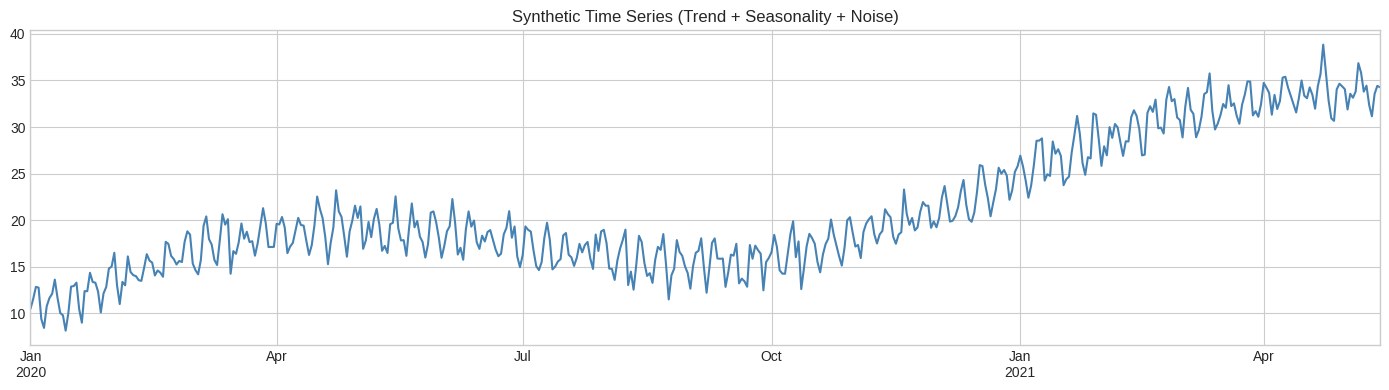

In [2]:
#  Generate synthetic time series 
np.random.seed(RANDOM_STATE)
n_periods = 500
dates = pd.date_range('2020-01-01', periods=n_periods, freq='D')
trend = np.linspace(10, 30, n_periods)
seasonality = 5 * np.sin(2 * np.pi * np.arange(n_periods) / 365)
weekly = 2 * np.sin(2 * np.pi * np.arange(n_periods) / 7)
noise = np.random.normal(0, 1, n_periods)
ts = trend + seasonality + weekly + noise

ts_series = pd.Series(ts, index=dates, name='value')
ts_df = pd.DataFrame({'ds': dates, 'y': ts})

plt.figure(figsize=(14,4))
ts_series.plot(color='steelblue')
plt.title('Synthetic Time Series (Trend + Seasonality + Noise)')
plt.tight_layout(); plt.show()

ADF Test:
  ADF Statistic: -0.2439
  p-value:       0.9331
  Series is NON-stationary

After differencing | p-value: 0.0008 → stationary


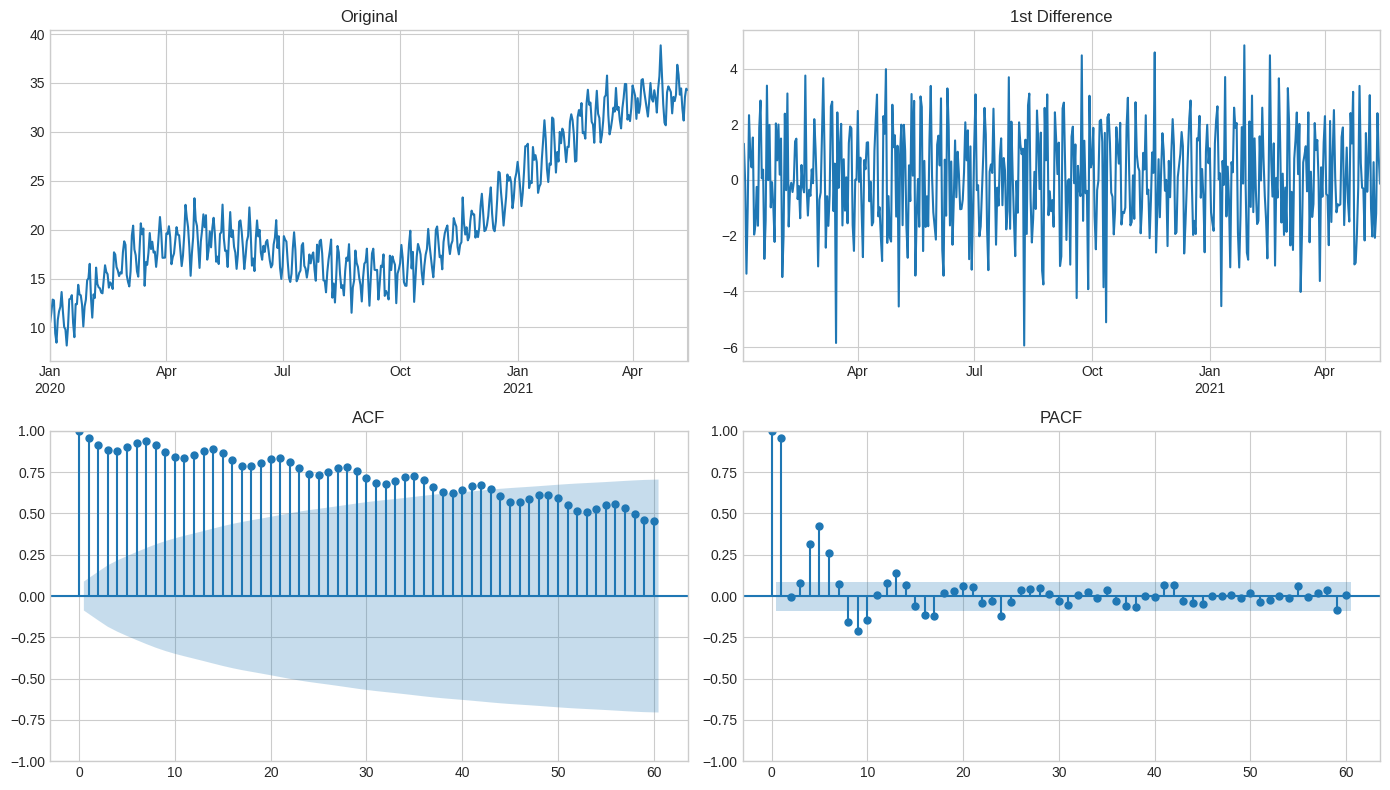

In [3]:
#  Stationarity Tests 
if SM_OK:
    adf_result = adfuller(ts_series.dropna())
    print('ADF Test:')
    print(f'  ADF Statistic: {adf_result[0]:.4f}')
    print(f'  p-value:       {adf_result[1]:.4f}')
    print(f'  Series is {"stationary" if adf_result[1] < 0.05 else "NON-stationary"}')

    # Differencing to make stationary
    ts_diff = ts_series.diff().dropna()
    adf2 = adfuller(ts_diff)
    print(f'\nAfter differencing | p-value: {adf2[1]:.4f} → {"stationary" if adf2[1] < 0.05 else "non-stationary"}')

    fig, axes = plt.subplots(2,2, figsize=(14,8))
    ts_series.plot(ax=axes[0,0], title='Original')
    ts_diff.plot(ax=axes[0,1], title='1st Difference')
    plot_acf(ts_series, lags=60, ax=axes[1,0], title='ACF')
    plot_pacf(ts_series, lags=60, ax=axes[1,1], title='PACF')
    plt.tight_layout(); plt.show()

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  470
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -799.950
Date:                Sat, 28 Mar 2026   AIC                           1609.901
Time:                        20:08:28   BIC                           1630.654
Sample:                    01-01-2020   HQIC                          1618.066
                         - 04-14-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1297      0.036     31.636      0.000       1.060       1.200
ar.L2         -0.7890      0.031    -25.097      0.000      -0.851      -0.727
ma.L1         -1.5543      0.043    -36.150      0.0

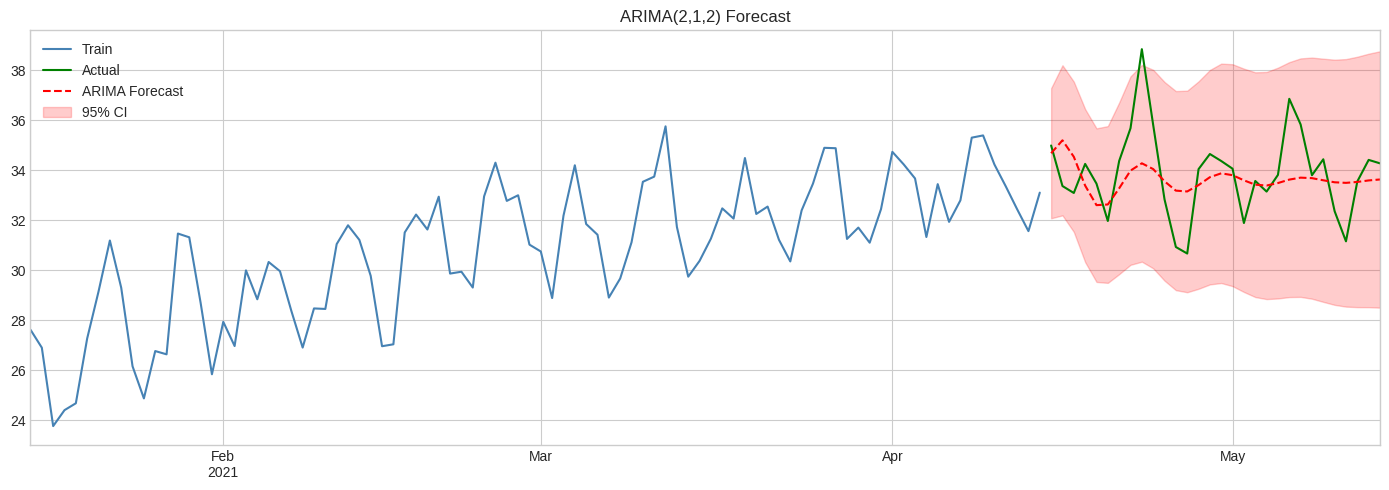

ARIMA | MAE: 1.2200 | RMSE: 1.5869


In [4]:
#  ARIMA Forecasting 
if SM_OK:
    train_ts = ts_series[:-30]
    test_ts  = ts_series[-30:]

    # Fit ARIMA(p,d,q)
    arima = ARIMA(train_ts, order=(2,1,2))
    arima_fit = arima.fit()
    print(arima_fit.summary())

    # Forecast
    forecast = arima_fit.forecast(steps=30)
    conf_int = arima_fit.get_forecast(steps=30).conf_int(alpha=0.05)

    plt.figure(figsize=(14,5))
    train_ts[-90:].plot(label='Train', color='steelblue')
    test_ts.plot(label='Actual', color='green')
    forecast.plot(label='ARIMA Forecast', color='red', linestyle='--')
    plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                     alpha=0.2, color='red', label='95% CI')
    plt.title('ARIMA(2,1,2) Forecast'); plt.legend()
    plt.tight_layout(); plt.show()

    mae = np.mean(np.abs(test_ts.values - forecast.values))
    rmse = np.sqrt(np.mean((test_ts.values - forecast.values)**2))
    print(f'ARIMA | MAE: {mae:.4f} | RMSE: {rmse:.4f}')

20:08:29 - cmdstanpy - INFO - Chain [1] start processing
20:08:29 - cmdstanpy - INFO - Chain [1] done processing


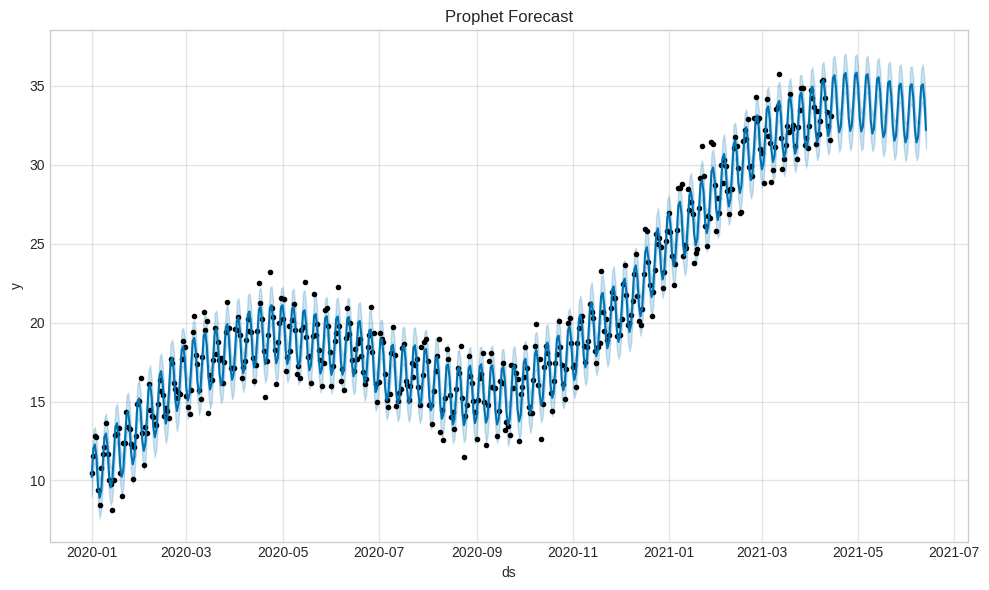

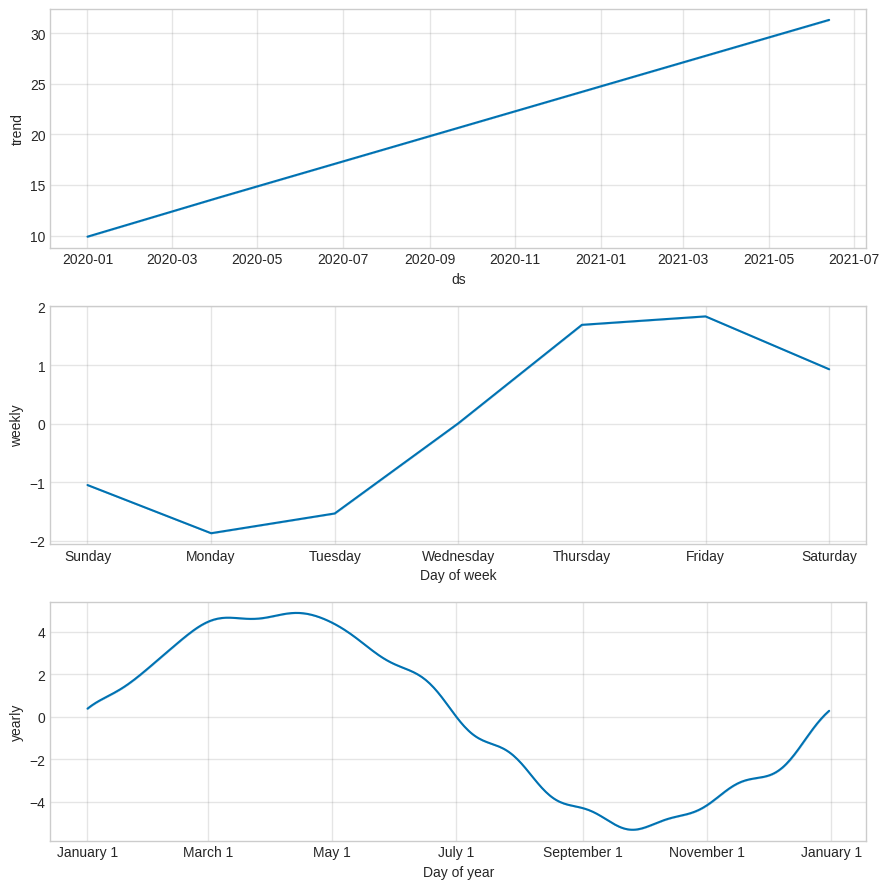

Prophet MAE: 1.0026


In [5]:
#  Prophet Forecasting 
try:
    from prophet import Prophet
    from prophet.diagnostics import cross_validation, performance_metrics

    train_p = ts_df.iloc[:-30]
    test_p  = ts_df.iloc[-30:]

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10
    )
    m.fit(train_p)

    future = m.make_future_dataframe(periods=60)
    forecast_p = m.predict(future)

    fig = m.plot(forecast_p)
    plt.title('Prophet Forecast'); plt.tight_layout(); plt.show()

    fig2 = m.plot_components(forecast_p)
    plt.tight_layout(); plt.show()

    mae_p = np.mean(np.abs(test_p['y'].values -
                            forecast_p[forecast_p['ds'].isin(test_p['ds'])]['yhat'].values))
    print(f'Prophet MAE: {mae_p:.4f}')
except ImportError:
    print('  pip install prophet')

I0000 00:00:1774728512.020505      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774728512.026647      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1774728516.466850     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


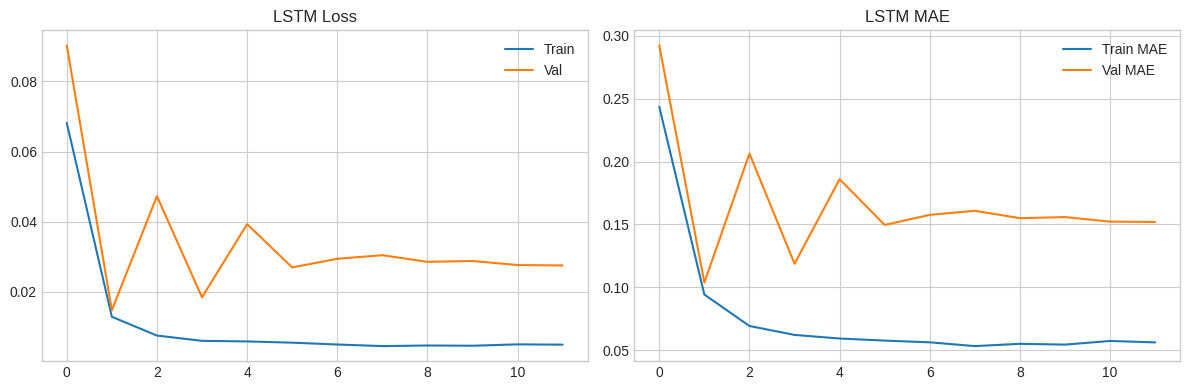

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
LSTM Test MAE: 6.0513


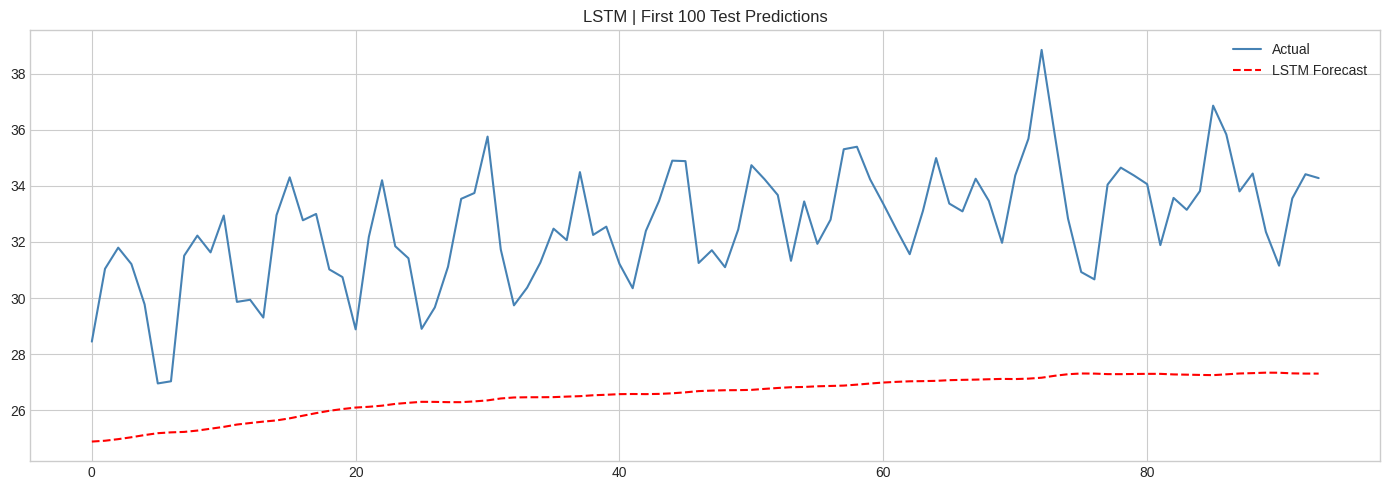

In [6]:
#  LSTM Time Series Forecasting 
def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

# Normalize
scaler_ts = MinMaxScaler()
ts_scaled = scaler_ts.fit_transform(ts_series.values.reshape(-1,1)).flatten()

SEQ_LEN = 30
X_seq, y_seq = create_sequences(ts_scaled, SEQ_LEN)
X_seq = X_seq[..., np.newaxis]  # (samples, timesteps, features)

split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

if TF_OK:
    tf.random.set_seed(RANDOM_STATE)

    model_lstm = models.Sequential([
        layers.Input(shape=(SEQ_LEN, 1)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])

    model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model_lstm.summary()

    cb = [
        callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(patience=5, factor=0.5)
    ]

    history = model_lstm.fit(
        X_tr, y_tr, epochs=100, batch_size=32,
        validation_split=0.15, callbacks=cb, verbose=0
    )

    # Plot training
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].plot(history.history['loss'], label='Train'); axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title('LSTM Loss'); axes[0].legend()
    axes[1].plot(history.history['mae'], label='Train MAE'); axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_title('LSTM MAE'); axes[1].legend()
    plt.tight_layout(); plt.show()

    y_pred_lstm = scaler_ts.inverse_transform(model_lstm.predict(X_te))
    y_true_lstm = scaler_ts.inverse_transform(y_te.reshape(-1,1))
    lstm_mae = np.mean(np.abs(y_true_lstm - y_pred_lstm))
    print(f'LSTM Test MAE: {lstm_mae:.4f}')

    plt.figure(figsize=(14,5))
    plt.plot(y_true_lstm[:100], label='Actual', color='steelblue')
    plt.plot(y_pred_lstm[:100], label='LSTM Forecast', color='red', linestyle='--')
    plt.title('LSTM | First 100 Test Predictions'); plt.legend()
    plt.tight_layout(); plt.show()
else:
    print('  TensorFlow not installed | skipping LSTM')

In [7]:
#  ML-based Time Series (Feature Engineering Approach) 
def make_ts_features(series, lags=7, rolling_windows=[7,14,30]):
    df = pd.DataFrame({'y': series})
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    for w in rolling_windows:
        df[f'roll_mean_{w}'] = df['y'].shift(1).rolling(w).mean()
        df[f'roll_std_{w}']  = df['y'].shift(1).rolling(w).std()
    df['trend'] = np.arange(len(df))
    df['month'] = pd.Series(ts_series.index).dt.month.values
    df['dow']   = pd.Series(ts_series.index).dt.dayofweek.values
    return df.dropna()

ts_feat = make_ts_features(ts_series.values)
X_ts_ml = ts_feat.drop('y', axis=1)
y_ts_ml = ts_feat['y']

split_ml = int(0.8 * len(X_ts_ml))
X_tr_ml, X_te_ml = X_ts_ml.iloc[:split_ml], X_ts_ml.iloc[split_ml:]
y_tr_ml, y_te_ml = y_ts_ml.iloc[:split_ml], y_ts_ml.iloc[split_ml:]

from sklearn.ensemble import GradientBoostingRegressor
gbr_ts = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                    learning_rate=0.05, random_state=RANDOM_STATE)
gbr_ts.fit(X_tr_ml, y_tr_ml)
y_pred_ml = gbr_ts.predict(X_te_ml)
print(f'GBR Time Series MAE: {np.mean(np.abs(y_te_ml - y_pred_ml)):.4f}')
print(f'GBR Time Series R²:  {1 - np.sum((y_te_ml-y_pred_ml)**2)/np.sum((y_te_ml-y_te_ml.mean())**2):.4f}')

GBR Time Series MAE: 2.7926
GBR Time Series R²:  -1.5385


## PART B: 🔍 Anomaly Detection

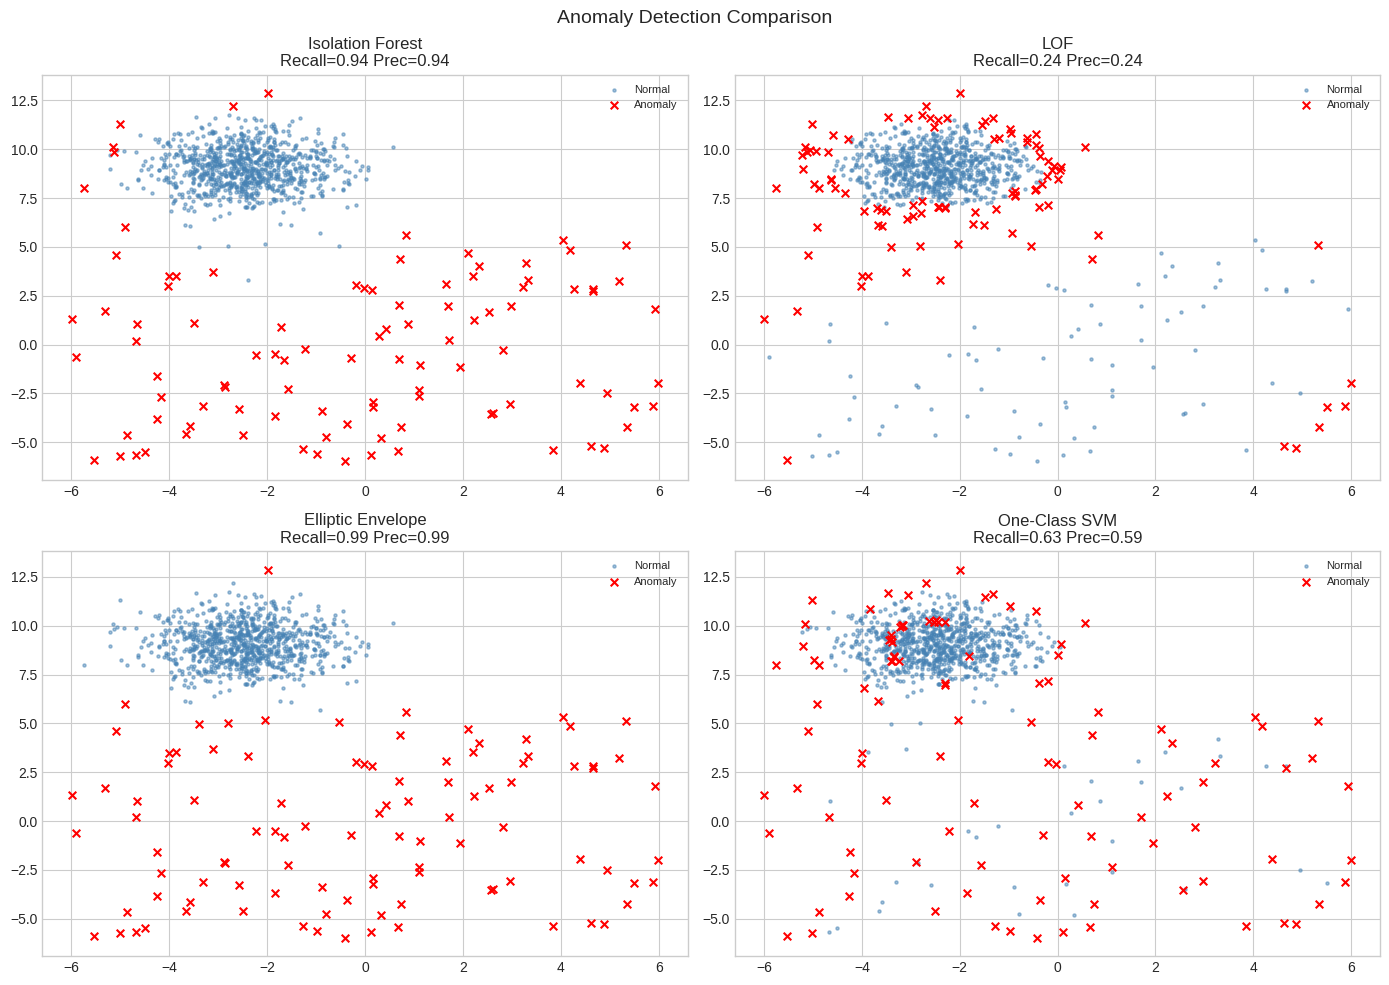

In [8]:
from sklearn.datasets import make_blobs

# Generate data with anomalies
X_norm, _ = make_blobs(n_samples=900, centers=1, cluster_std=1.0, random_state=RANDOM_STATE)
X_anom = np.random.uniform(-6, 6, size=(100, 2))
X_ad = np.vstack([X_norm, X_anom])
y_ad = np.array([1]*900 + [-1]*100)  # 1=normal, -1=anomaly

detectors = {
    'Isolation Forest':   IsolationForest(contamination=0.1, random_state=RANDOM_STATE),
    'LOF':                LocalOutlierFactor(n_neighbors=20, contamination=0.1),
    'Elliptic Envelope':  EllipticEnvelope(contamination=0.1, random_state=RANDOM_STATE),
    'One-Class SVM':      OneClassSVM(nu=0.1, kernel='rbf', gamma='auto'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, det) in zip(axes.flat, detectors.items()):
    preds = det.fit_predict(X_ad)
    tp = np.sum((preds==-1) & (y_ad==-1))  # true anomalies caught
    fp = np.sum((preds==-1) & (y_ad==1))
    recall = tp / 100
    prec   = tp / (tp + fp) if (tp+fp) > 0 else 0
    ax.scatter(X_ad[preds==1,0],  X_ad[preds==1,1],  c='steelblue', s=5, alpha=0.5, label='Normal')
    ax.scatter(X_ad[preds==-1,0], X_ad[preds==-1,1], c='red', s=30, marker='x', label='Anomaly')
    ax.set_title(f'{name}\nRecall={recall:.2f} Prec={prec:.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Anomaly Detection Comparison', fontsize=14)
plt.tight_layout(); plt.show()

## PART C: 🏷️ Multi-label & Multi-output Prediction

In [9]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import hamming_loss, jaccard_score

X_ml, Y_ml = make_multilabel_classification(
    n_samples=2000, n_features=20, n_classes=5,
    n_labels=2, random_state=RANDOM_STATE
)
X_ml_tr, X_ml_te, Y_ml_tr, Y_ml_te = train_test_split(
    X_ml, Y_ml, test_size=0.2, random_state=RANDOM_STATE
)

#  One-vs-Rest with Random Forest 
rf_ovr = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
rf_ovr.fit(X_ml_tr, Y_ml_tr)
Y_pred_ml = rf_ovr.predict(X_ml_te)

print('Multi-label Metrics:')
print(f'  Hamming Loss:        {hamming_loss(Y_ml_te, Y_pred_ml):.4f} (lower=better)')
print(f'  Jaccard Score (avg): {jaccard_score(Y_ml_te, Y_pred_ml, average="samples"):.4f}')
print(f'  F1 (micro):          {f1_score(Y_ml_te, Y_pred_ml, average="micro"):.4f}')
print(f'  F1 (macro):          {f1_score(Y_ml_te, Y_pred_ml, average="macro"):.4f}')

# Per-label accuracy
for i in range(Y_ml_te.shape[1]):
    acc = np.mean(Y_pred_ml[:,i] == Y_ml_te[:,i])
    print(f'  Label {i} accuracy: {acc:.4f}')

Multi-label Metrics:
  Hamming Loss:        0.1840 (lower=better)
  Jaccard Score (avg): 0.6268
  F1 (micro):          0.7294
  F1 (macro):          0.6551
  Label 0 accuracy: 0.8000
  Label 1 accuracy: 0.7875
  Label 2 accuracy: 0.8125
  Label 3 accuracy: 0.8200
  Label 4 accuracy: 0.8600


## PART D: 📊 Calibration & Threshold Optimization

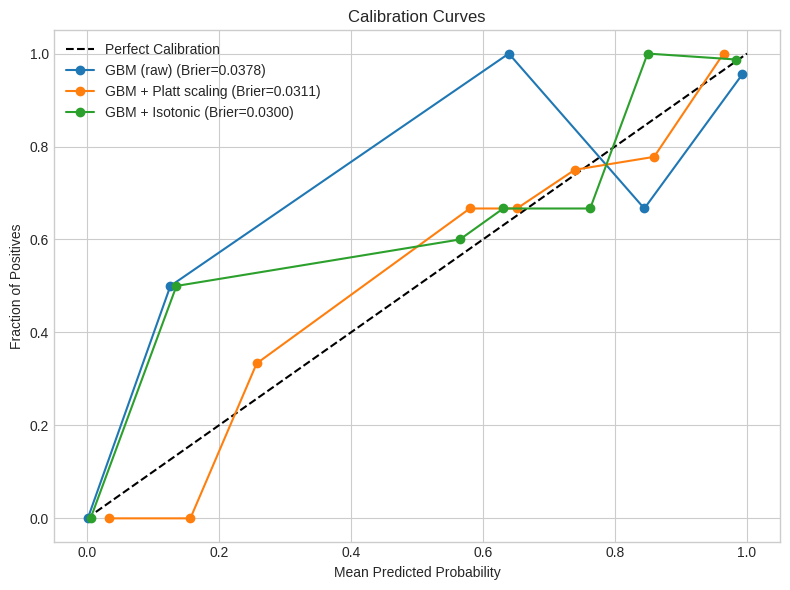

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import GradientBoostingClassifier

cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(X_c, y_c, test_size=0.25, random_state=RANDOM_STATE, stratify=y_c)

models_cal = {
    'GBM (raw)':           GradientBoostingClassifier(random_state=RANDOM_STATE),
    'GBM + Platt scaling': CalibratedClassifierCV(GradientBoostingClassifier(random_state=RANDOM_STATE), method='sigmoid', cv=5),
    'GBM + Isotonic':      CalibratedClassifierCV(GradientBoostingClassifier(random_state=RANDOM_STATE), method='isotonic', cv=5),
}

plt.figure(figsize=(8,6))
plt.plot([0,1],[0,1],'k--', label='Perfect Calibration')

for name, m in models_cal.items():
    m.fit(X_c_tr, y_c_tr)
    prob = m.predict_proba(X_c_te)[:,1]
    frac_pos, mean_pred = calibration_curve(y_c_te, prob, n_bins=10)
    brier = brier_score_loss(y_c_te, prob)
    plt.plot(mean_pred, frac_pos, marker='o', label=f'{name} (Brier={brier:.4f})')

plt.xlabel('Mean Predicted Probability'); plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves'); plt.legend()
plt.tight_layout(); plt.show()

Best F1 Threshold: 0.118
  Precision: 0.9474
  Recall:    1.0000
  F1:        0.9730


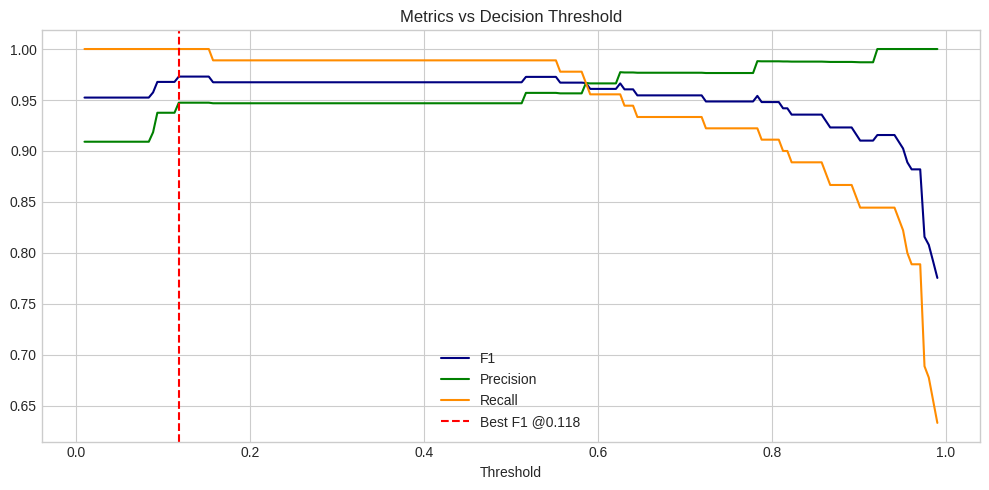

In [11]:
#  Threshold Optimization 
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve

best_cal = list(models_cal.values())[-1]  # Isotonic
y_prob_cal = best_cal.predict_proba(X_c_te)[:,1]

thresholds = np.linspace(0.01, 0.99, 200)
metrics_thr = []
for t in thresholds:
    y_pred_t = (y_prob_cal >= t).astype(int)
    metrics_thr.append({
        'threshold': t,
        'precision': precision_score(y_c_te, y_pred_t, zero_division=0),
        'recall':    recall_score(y_c_te, y_pred_t, zero_division=0),
        'f1':        f1_score(y_c_te, y_pred_t, zero_division=0),
    })

thr_df = pd.DataFrame(metrics_thr)
best_f1_thr = thr_df.loc[thr_df['f1'].idxmax()]
print(f'Best F1 Threshold: {best_f1_thr["threshold"]:.3f}')
print(f'  Precision: {best_f1_thr["precision"]:.4f}')
print(f'  Recall:    {best_f1_thr["recall"]:.4f}')
print(f'  F1:        {best_f1_thr["f1"]:.4f}')

plt.figure(figsize=(10,5))
plt.plot(thr_df['threshold'], thr_df['f1'], label='F1', color='navy')
plt.plot(thr_df['threshold'], thr_df['precision'], label='Precision', color='green')
plt.plot(thr_df['threshold'], thr_df['recall'], label='Recall', color='darkorange')
plt.axvline(best_f1_thr['threshold'], color='red', linestyle='--', label=f'Best F1 @{best_f1_thr["threshold"]:.3f}')
plt.xlabel('Threshold'); plt.title('Metrics vs Decision Threshold')
plt.legend(); plt.tight_layout(); plt.show()

## PART E: 🧠 Neural Network | PyTorch Custom Training Loop

PyTorch Net | Final Val Accuracy: 0.9930


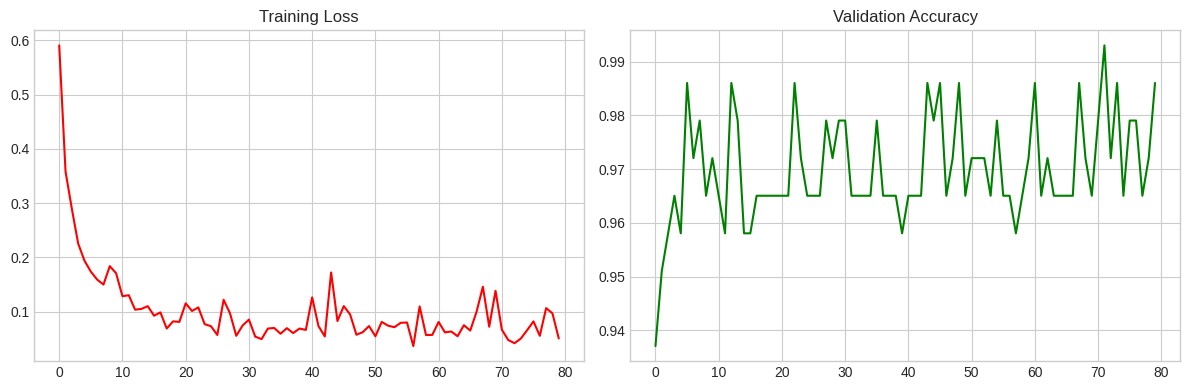

In [12]:
if TORCH_OK:
    torch.manual_seed(RANDOM_STATE)

    class TabularNet(nn.Module):
        def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.3):
            super().__init__()
            layers_list = []
            in_dim = input_dim
            for h in hidden_dims:
                layers_list += [
                    nn.Linear(in_dim, h),
                    nn.BatchNorm1d(h),
                    nn.ReLU(),
                    nn.Dropout(dropout)
                ]
                in_dim = h
            layers_list.append(nn.Linear(in_dim, output_dim))
            self.net = nn.Sequential(*layers_list)

        def forward(self, x):
            return self.net(x)

    # Prepare data
    scaler_nn = StandardScaler()
    X_nn_tr = torch.FloatTensor(scaler_nn.fit_transform(X_c_tr))
    X_nn_te = torch.FloatTensor(scaler_nn.transform(X_c_te))
    y_nn_tr = torch.LongTensor(y_c_tr)
    y_nn_te = torch.LongTensor(y_c_te)

    dataset_tr = TensorDataset(X_nn_tr, y_nn_tr)
    loader_tr  = DataLoader(dataset_tr, batch_size=32, shuffle=True)

    model_nn = TabularNet(input_dim=30, hidden_dims=[128, 64, 32], output_dim=2, dropout=0.3)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_nn.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    train_losses, val_accs = [], []
    EPOCHS = 80

    for epoch in range(EPOCHS):
        model_nn.train()
        epoch_loss = 0
        for Xb, yb in loader_tr:
            optimizer.zero_grad()
            loss = criterion(model_nn(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model_nn.eval()
        with torch.no_grad():
            logits = model_nn(X_nn_te)
            acc = (logits.argmax(1) == y_nn_te).float().mean().item()
        train_losses.append(epoch_loss / len(loader_tr))
        val_accs.append(acc)
        scheduler.step()

    print(f'PyTorch Net | Final Val Accuracy: {max(val_accs):.4f}')

    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].plot(train_losses, color='red'); axes[0].set_title('Training Loss')
    axes[1].plot(val_accs, color='green'); axes[1].set_title('Validation Accuracy')
    plt.tight_layout(); plt.show()
else:
    print('  PyTorch not installed | skipping NN')

In [13]:
#  sklearn MLP (quick alternative) 
mlp = Pipeline([
    ('sc', StandardScaler()),
    ('m', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=32,
        learning_rate='adaptive',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=RANDOM_STATE
    ))
])
mlp.fit(X_c_tr, y_c_tr)
mlp_prob = mlp.predict_proba(X_c_te)[:,1]
print(f'sklearn MLP AUC: {roc_auc_score(y_c_te, mlp_prob):.4f}')
print(f'sklearn MLP Acc: {mlp.score(X_c_te, y_c_te):.4f}')

sklearn MLP AUC: 0.9906
sklearn MLP Acc: 0.9371


## PART F: ⏱️ Time Series Cross-Validation

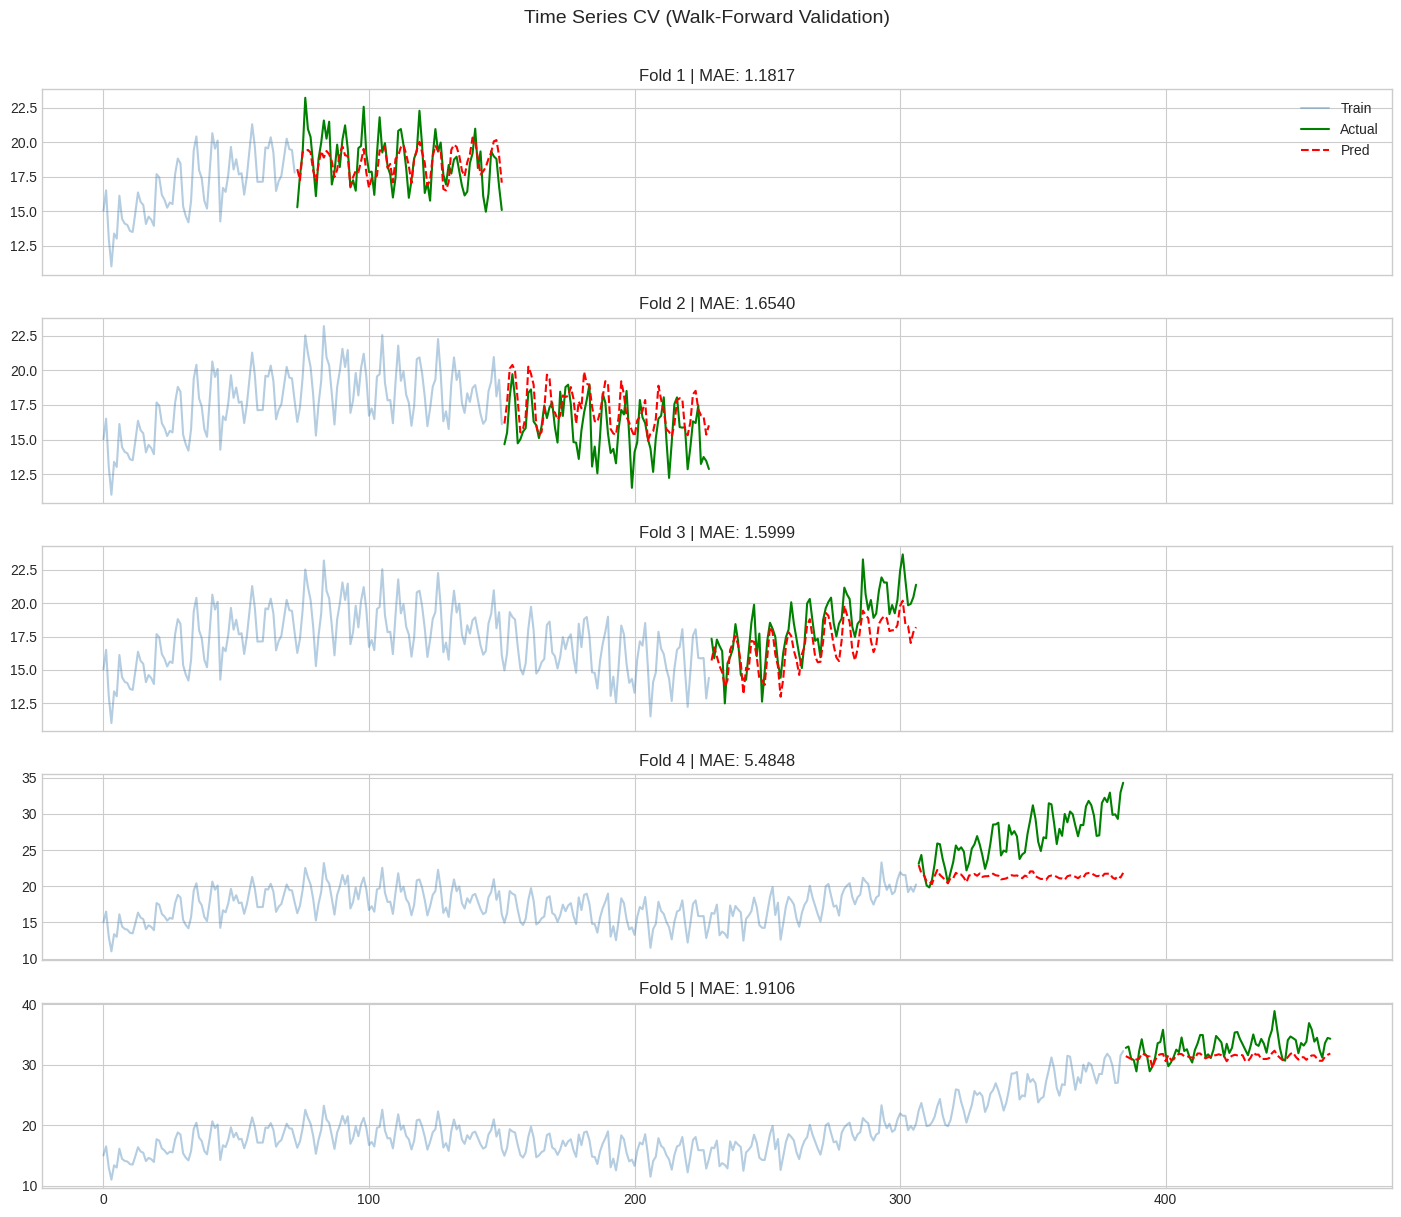


Mean CV MAE: 2.3662 ± 1.5768


In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor

tscv = TimeSeriesSplit(n_splits=5, gap=7)
X_ts_arr = X_ts_ml.values
y_ts_arr  = y_ts_ml.values

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fold_maes = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_ts_arr)):
    X_f_tr, X_f_te = X_ts_arr[tr_idx], X_ts_arr[te_idx]
    y_f_tr, y_f_te = y_ts_arr[tr_idx], y_ts_arr[te_idx]

    gbr = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
    gbr.fit(X_f_tr, y_f_tr)
    y_f_pred = gbr.predict(X_f_te)
    mae = np.mean(np.abs(y_f_te - y_f_pred))
    fold_maes.append(mae)

    axes[fold].plot(range(len(tr_idx)), y_f_tr, color='steelblue', alpha=0.4, label='Train')
    axes[fold].plot(range(len(tr_idx), len(tr_idx)+len(te_idx)), y_f_te,
                    color='green', label='Actual')
    axes[fold].plot(range(len(tr_idx), len(tr_idx)+len(te_idx)), y_f_pred,
                    color='red', linestyle='--', label='Pred')
    axes[fold].set_title(f'Fold {fold+1} | MAE: {mae:.4f}')
    if fold == 0: axes[fold].legend()

plt.suptitle('Time Series CV (Walk-Forward Validation)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
print(f'\nMean CV MAE: {np.mean(fold_maes):.4f} ± {np.std(fold_maes):.4f}')

## PART G: 💾 Model Serialization & Serving

In [15]:
import joblib, pickle, json, os

# Best model from classification
best_pipeline = Pipeline([
    ('sc', StandardScaler()),
    ('m', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
])
best_pipeline.fit(X_c_tr, y_c_tr)

#  Save with joblib (recommended for sklearn) 
joblib.dump(best_pipeline, 'model_pipeline.joblib', compress=3)
print(' Saved with joblib')

#  Save with pickle 
with open('model_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)
print(' Saved with pickle')

#  Save metadata 
metadata = {
    'model_name':    'RandomForest Classifier',
    'n_features':    X_c_tr.shape[1],
    'feature_names': cancer.feature_names.tolist(),
    'target_names':  cancer.target_names.tolist(),
    'test_auc':      round(roc_auc_score(y_c_te, best_pipeline.predict_proba(X_c_te)[:,1]), 4),
    'trained_on':    str(datetime.now()),
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(' Metadata saved')

#  Load and verify 
loaded_model = joblib.load('model_pipeline.joblib')
auc_loaded = roc_auc_score(y_c_te, loaded_model.predict_proba(X_c_te)[:,1])
print(f'\n Loaded model AUC: {auc_loaded:.4f}')
print('Model is production-ready! 🚀')

 Saved with joblib
 Saved with pickle
 Metadata saved

 Loaded model AUC: 0.9951
Model is production-ready! 🚀


In [16]:
#  Production Inference Function 
def predict_single(model, input_dict, feature_names, threshold=0.5):
    """
    Production-style inference wrapper.
    input_dict: {feature_name: value, ...}
    Returns: {'prediction': int, 'probability': float, 'confidence': str}
    """
    df_input = pd.DataFrame([input_dict])[feature_names]
    prob = model.predict_proba(df_input)[0, 1]
    pred = int(prob >= threshold)
    conf = 'HIGH' if abs(prob - 0.5) > 0.3 else 'MEDIUM' if abs(prob - 0.5) > 0.15 else 'LOW'
    return {'prediction': pred, 'probability': round(float(prob), 4), 'confidence': conf}

# Example single prediction
sample = dict(zip(cancer.feature_names, X_c_te[0]))
result = predict_single(loaded_model, sample, cancer.feature_names)
print('Sample Prediction Result:')
print(json.dumps(result, indent=2))
print(f'True label: {cancer.target_names[y_c_te[0]]}')

# Batch prediction
def predict_batch(model, df, feature_names, threshold=0.5):
    probs = model.predict_proba(df[feature_names])[:,1]
    preds = (probs >= threshold).astype(int)
    df_out = df.copy()
    df_out['pred_prob'] = probs
    df_out['prediction'] = preds
    return df_out

test_results = predict_batch(loaded_model, pd.DataFrame(X_c_te, columns=cancer.feature_names),
                              cancer.feature_names)
print(f'\nBatch prediction complete: {len(test_results)} samples')
display(test_results[['pred_prob','prediction']].describe())

Sample Prediction Result:
{
  "prediction": 1,
  "probability": 0.98,
  "confidence": "HIGH"
}
True label: benign

Batch prediction complete: 143 samples


,pred_prob,prediction
count,143.000000,143.000000
mean,0.620490,0.643357
std,0.434011,0.480692
min,0.000000,0.000000
25%,0.050000,0.000000
50%,0.900000,1.000000
75%,0.990000,1.000000
max,1.000000,1.000000


##  Full Summary

| Topic | Tools Used |
|---|---|
| Time Series EDA | adfuller, plot_acf, plot_pacf |
| ARIMA | statsmodels ARIMA, SARIMAX |
| Prophet | facebook/prophet with tuning |
| LSTM | TensorFlow/Keras LSTM |
| ML-based TS | GBR + lag/rolling features |
| Walk-forward CV | TimeSeriesSplit |
| Anomaly Detection | IsolationForest, LOF, OCSVM |
| Multi-label | MultiOutputClassifier, hamming loss |
| Calibration | CalibratedClassifierCV, calibration_curve |
| Threshold Opt | F1/Prec/Recall vs threshold sweep |
| PyTorch MLP | Custom net + BatchNorm + Dropout |
| sklearn MLP | MLPClassifier with early stopping |
| Model Saving | joblib, pickle, JSON metadata |
| Serving | Inference wrapper with confidence |
